Proof of <a class="ProveItLink" href="../../../../../../_theory_nbs_/theory.ipynb">proveit</a>.<a class="ProveItLink" href="../../../../../_theory_nbs_/theory.ipynb">physics</a>.<a class="ProveItLink" href="../../../../_theory_nbs_/theory.ipynb">quantum</a>.<a class="ProveItLink" href="../../theory.ipynb">QEC2</a>.<a class="ProveItLink" href="../../theorems.ipynb#buf_gen_graph_complete">buf_gen_graph_complete</a> theorem
========

In [ ]:
import proveit
theory = proveit.Theory() # the theorem's theory
from proveit                 import defaults, display_provers # useful imports
from proveit                 import b, f, g, k, p, s, X, Y, ExprTuple, Function, Lambda, Variable
from proveit.core_expr_types import f_1_to_k
from proveit.logic           import And, Equals, Exists, Forall, InSet
from proveit.logic.sets      import Card, EmptySet, Set, SubsetEq
from proveit.graphs          import EdgeSequence, PathsOf
from proveit.numbers         import zero, one, LessEq

from proveit.physics.quantum.QEC2 import (
        _nu, _start, AllStatesGraph, BufiloGeneratingGraph, Errors,
        Faults, IrreducibleBufiloSets, Realizations, s_prime, State)


In [ ]:
%proving buf_gen_graph_complete

##### We are considering all “irreducible BUFILOS” $b$ of a restricted weight $w(b) \le w_{\text{BUF}}$, so we add those assumptions to the default assumptions:

In [ ]:
defaults.assumptions = buf_gen_graph_complete.all_conditions()

We proceed using a proof by induction on the number of faults $k$ used to generate a path from the START state $\{\ell\}$ (on the way to the END state $\emptyset$), with the goal of proving the following sub-theorem:

In [ ]:
sub_thm = Forall(k,
       
       Exists(p,
       Exists((f_1_to_k),
       
              And(InSet(ExprTuple(f_1_to_k), Realizations(EdgeSequence(p), BufiloGeneratingGraph)),
                  SubsetEq(Set(f_1_to_k), b)),
              
       domain=Faults).with_wrapping(), # end exists f1..fk
       domain=PathsOf(BufiloGeneratingGraph, begin=_start)).with_wrapping(), # end exists p
       
conditions=[LessEq(k, Card(b))]).with_wrapping() # end Forall k

##### To prove the sub-theorem, then, we have the following (Lambda-defined) propositional function:

In [ ]:
P = Lambda(k, sub_thm.instance_expr)

##### ALT

##### We want to show that $P(0)$ is TRUE, and that for $k < |b|$ we have $P(k) \Rightarrow P(k+1)$.

#### Base Case: $P(0)$

In [ ]:
P.apply(zero)

##### The proposed path is the trivial (_i.e._, single-vertex) path $p = (\text{START})$, with corresponding empty set of faults $\emptyset \subseteq b$ forming the empty sequence of faults $()$ such that $() \in \text{Realizations}(\text{EdgeSeq}(p), G_{\ell \nu}^{BUF}) = \text{Realizations}((), G_{\ell \nu}^{BUF}) \equiv \{()\}$.

Given the “RealizationSets” approach, the inductive statement would then become something like this:

$\forall_{k \le |b|}\big[
\exists_{a \subseteq b | |a|=k}\big[a \in \text{Realizations}(\text{EdgeSeq}(p), G)\big]\big]$


##### <br/>We want to show that $P(1)$ is TRUE, and that for $k < |b|$,  $P(k) \Rightarrow P(k+1)$ .

#### Base Case: $P(1)$

##### We want to establish that $P(1)$ is TRUE, where $P(1)$ is given by:

In [ ]:
P.apply(one)

##### Proposed path $p = (\text{START}, H(\{f\}))$, where $f\in b$ with $A_{\ell}(\{f\}) = 1$ so that $\text{Obs}_{\ell}(\{f\}) = H(\{f\})) \cup \{\ell\}$.

Because of the structure of the BUFILO-generating graph $G_{\ell v}^{\text{BUF}}$, any path $p$ starting at the START node $\{\ell\}$ must begin along an edge corresponding to a fault $f$ that anti-commutes with $\ell$ (_i.e._, $A_{\ell}(\{f\}) = 1$).  The proposed path $p$ will be the single-edge path $p = (\text{START}, H(\{f\}))$, where we take $f \in b$ such that $A_{\ell}(\{f\}) = 1$ (and thus $\text{Obs}_{\ell}(\{f\}) = H(\{f\}) \cup \{\ell\}$).

We need to prove that such a fault $f \in b$ exists, and prove that the proposed path $p$ is in fact a path in $G_{\ell v}^{BUF}$.

#### Base Case, Part (1): $\exists_{f \in b}\big[A_{\ell}(\{f\}) = 1\big]$.

In [ ]:
# For convenience, we label this assumption
b_in_ibufs = InSet(b, IrreducibleBufiloSets)

In [ ]:
b_in_ibufs_unfold = b_in_ibufs.unfold()

In [ ]:
b_in_ibufs_unfold_2 = b_in_ibufs_unfold.expr.operands[0].unfold()

In [ ]:
b_is_set_of_faults = InSet(b, Errors).unfold()

In [ ]:
# We Skolemize, choosing a label for the existent n,
# and providing labels for the resulting assumptions added defaults.assumptions:
n_star = Variable('n*', r'n^{*}')
n_star_in_Nat, exists_faults_for_b = b_is_set_of_faults.choose(n_star)

In [ ]:
# We Skolemize once again; in this case we have to let Prove-It
# simply use the same labels for the f1, f2, ..., fn*
each_f_in_faults, b_is_set_of_fs = exists_faults_for_b.choose()

In [ ]:
# quickly review the default assumptions:
defaults.assumptions

##### We know that an error $e$ that anti-commutes with $\ell$ contains a fault that anti-commutes with $\ell$:

In [ ]:
from proveit.physics.quantum.QEC2 import anticommuting_error_contains_anticommuting_fault
anticommuting_error_contains_anticommuting_fault

In [ ]:
from proveit import e
exists_f_in_b_that_anticommutes = anticommuting_error_contains_anticommuting_fault.instantiate({e:b})

##### We Skolemize, labeling the desired fault $f$ as $f^{*}$:

In [ ]:
f_star = Variable('f*', r'f^{*}')
f_star_in_b, f_star_anticommutes = exists_f_in_b_that_anticommutes.choose(f_star)

##### SUMMARY: We now have shown that there does indeed exist a fault $f \in b$ such that $A_{\ell}(\{f\}) = 1$, and we have labeled that fault $f^{*}$.

#### Base Case, Part (2):

##### Show that the graph node sequence $(\text{START}, H(\{f^{*}\}) = (\{\ell\}, H(\{f^{*}\}))$ forms a path in the BUFILO-generating graph $G_{\ell v}^{BUF}$.

##### To do that, we need to show that:
- $(\text{START}, H(\{f^{*}\})) \in \text{WalksOf}(G_{\ell v}^{BUF}, \text{START} \to)$, with $\text{START} \ne H(\{f^{*}\})$.

And to show that $(\text{START}, H(\{f^{*}\})) \in \text{WalksOf}(G_{\ell v}^{BUF}, \text{START} \to)$, we need to show that:

- $\text{START}, H(\{f^{*}\}) \in \text{Vertices}(G_{\ell v}^{BUF})$ and that $\text{START}$ and $H(\{f^{*}\})$ are adjacent in $G_{\ell v}^{BUF}$.

In [ ]:
from proveit.physics.quantum.QEC2 import _ell, CheckFunction, ObservableSet
# For convenience we label the two graph nodes of interest:
s0, s1 = (_start, CheckFunction(Set(f_star)))

##### Recall the definition of the BUFILO-generating graph $G_{\ell v}^{BUF}$:

In [ ]:
from proveit.physics.quantum.QEC2 import BufiloGeneratingGraph
buf_gen_graph_def = BufiloGeneratingGraph.definition()

In [ ]:
# and while we're at it:
from proveit.physics.quantum.QEC2 import buf_gen_graph_is_graph
buf_gen_graph_is_graph

The vertex set for the BUFILO-generating graph $G_{\ell v}^{BUF}$ is the set of all observable sets $\text{ObsSets}_{\ell}$, but we need to make this explicit, and the vertices of an explicitly defined graph of the form $\text{Graph}(V, E)$ are obtained as follows (some opportunities for automation here):

In [ ]:
from proveit.graphs import vertices_def
vertices_def

In [ ]:
from proveit import E, V
from proveit.physics.quantum.QEC2 import ObservableSets
vertices_are_obs_sets = vertices_def.instantiate({V:ObservableSets, E:buf_gen_graph_def.rhs.operands[1]})

In [ ]:
vertices_are_obs_sets.inner_expr().lhs.operand.substitute(buf_gen_graph_def.derive_reversed())

In [ ]:
from proveit.physics.quantum.QEC2 import start_is_obs_set
start_is_obs_set

In [ ]:
# this should eventually be automated, possibly in a FaultsMembership.conclude() method
from proveit.physics.quantum.QEC2 import err_elem_is_fault
err_elem_is_fault

In [ ]:
err_elem_is_fault.instantiate({e:b, f:f_star})

In [ ]:
InSet(s1, ObservableSets).prove()

In [ ]:
from proveit.graphs import Vertices
InSet(s0, Vertices(BufiloGeneratingGraph)).prove()

In [ ]:
InSet(s1, Vertices(BufiloGeneratingGraph)).prove()

##### Thus we have that $\text{START} \in \text{Vertices}\big(G_{\ell v}^{BUF}\big)$ and $\text{Obs}_{\ell}(\{f^{*}\}) \in \text{Vertices}\big(G_{\ell v}^{BUF}\big)$.

We still need to prove that the two states are adjacent in the BUFILO-generating graph $G_{\ell v}^{BUF}$, which amounts to proving that the pair form an edge in $G_{\ell v}^{BUF}$.

In [ ]:
from proveit.graphs import edges_def
edges_def

In [ ]:
edges_of_graph = edges_def.instantiate({V:ObservableSets, E:buf_gen_graph_def.rhs.operands[1]})

In [ ]:
edges_of_graph_general = edges_of_graph.inner_expr().lhs.operand.substitute(buf_gen_graph_def.derive_reversed())

In [ ]:
# For convenience, let's give the edge set a label
edge_set = edges_of_graph.rhs

##### Here we work on showing that $\nu(s_{0}) \in s_{0} - s_{1}$.

In [ ]:
from proveit.physics.quantum.QEC2 import nu_start_is_ell
nu_start_is_ell

In [ ]:
from proveit.physics.quantum.QEC2 import start_disjoint_from_fault_syndrome
start_disjoint_from_fault_syndrome

In [ ]:
start_disjoint_from_fault_syndrome.instantiate({f:f_star})

In [ ]:
from proveit.logic.sets import Disjoint
Disjoint(s0, s1).prove()

In [ ]:
from proveit.logic.sets import Difference
Difference(s0, s1).simplification()

In [ ]:
from proveit.physics.quantum.QEC2 import start_is_ell
start_is_ell

In [ ]:
# and we seem to need to make this explicit
# InSet(Function(_nu, s0), Difference(s0, s1)).prove()
# InSet(_ell, _start).prove()
# InSet(_ell, Set(_ell)).prove()

In [ ]:
InSet(_ell, Set(_ell)).prove()

In [ ]:
InSet(Function(_nu, s0), Difference(s0, s1)).prove()

##### Despite having the conditions established, directly proving $(s_{0}, s_{1}) \in \text{Edges}(G_{\ell \nu}^{BUF})$ using .prove() hits some problems (this is not surprising):

In [ ]:
# A direct attempt still runs into trouble
# InSet(ExprTuple(s0, s1), edge_set).prove()

##### So we manually establish one of the existence claims that the SetOfAll.conclude() method would normally use:

In [ ]:
exist_stmt = Exists((s, s_prime),
                    Equals(ExprTuple(s0, s1), ExprTuple(s, s_prime)),
                    conditions=[InSet(Function(_nu, s), Difference(s, s_prime))],
                    domain=ObservableSets).conclude_via_example((s0, s1))

##### And now we can derive the desired conclusion:

In [ ]:
InSet(ExprTuple(s0, s1), edge_set).prove()

In [ ]:
# just checking:
edge_in_edge_set = InSet(ExprTuple(s0, s1), edge_set).prove()

In [ ]:
edge_in_edge_set.inner_expr().domain.substitute(edges_of_graph_general.derive_reversed())

In [ ]:
from proveit.graphs import AdjacentVertices
AdjacentVertices(s0, s1, BufiloGeneratingGraph).definition()

In [ ]:
# AdjacentVertices(s0, s1, BufiloGeneratingGraph).definition().rhs.prove()

##### Can we at least establish that $s0 \ne s1$? Since we have $\text{Disjoint}(s_{0}, s_{1})$, $s0$ and $s1$ are clearly not the same.

Is it too indulgent to invoke a theorem something along the lines of:

$\forall_{A, B \,|\, \text{Disjoint(A, B)}}\big[A \ne B\big]$

In [ ]:
from proveit.logic import NotEquals
# NotEquals(s0, s1).prove()

#### Inductive Step: $P(k) \Rightarrow P(k+1)$

##### We want to establish that, for $k < |b|$, we have $P(k) \Rightarrow P(k+1)$, where $P(k)$ is given by:

In [ ]:
Pk = P.apply(k)

##### We add $P(k)$ to our assumptions, and then prove that $P(k+1)$ holds:

In [ ]:
defaults.assumptions = defaults.assumptions + [Pk]

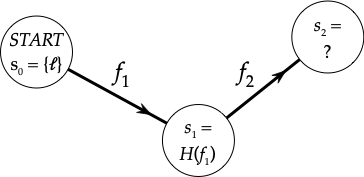

Going from START to $s_{1}$, we found a fault $f_{1} \in b$ such that $A_{\ell}(f_{1}) = 1$ and thus $\text{Obs}_{\ell}(\{f_{1}\}) = H(\{f_{1}\}) \cup \{\ell\}$.

Then we have: $s_{1} = s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) = s_{0} \triangle \big(H(\{f_{1}\}) \cup \{\ell\}\big) = H(\{f_{1}\})$.

What is $s_{2}$?

We choose $f_{2} \in \big(b - \{f_{1}\}\big)$ such that $\text{Obs}_{\ell}(\{f_{2}\}) \cap H(\{f_{1}\}) \ne \emptyset$.

Then $s_{2} = s_{1} \triangle \text{Obs}_{\ell}(\{f_{2}\}) = s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\})$?

Generalizing this idea, we have:

$s_{k} = s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{k}\})$

A related “partitioning” theorem

$s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{n}\}) = \emptyset$

$\forall_{A, B}\big(A \triangle B = \emptyset \Rightarrow A = B\big)$

$\big(s_{k} \triangle \big(\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big)\} = \emptyset \Rightarrow s_{k} = \big(\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big)\big)$



$\big(s_{k} \triangle \big(\text{Obs}_{\ell}(\{f_{k+1}, f_{k+2}, \ldots, f_{n}\})\big) = \emptyset \Rightarrow s_{k} = \big(\text{Obs}_{\ell}(\{f_{k+1}, f_{k+2}, \ldots, f_{n}\})\big)\big)$

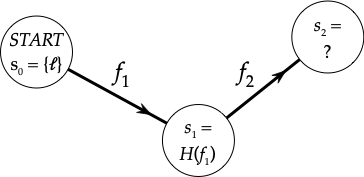

In [ ]:
Pk

Assuming $P(k)$ is True, means (as illustrated above) that there exists a path $p$ and the $k$ faults $f_{1}, \ldots, f_{k}$ such that $(f_{1}, \ldots, f_{k}) \in \text{Realizations}(\text{EdgeSeq}(p), G_{\ell \nu}^{BUF})$ and $\{f_{1}, \ldots, f_{k}\} \subseteq b$. We can Skolemize, and for convenience just use the same variable labels, so that $p$ is our path in $G_{\ell \nu}^{BUF}$ and $f_{1}, f_{2}, \ldots, f_{n}$ are the associated faults.

The “proposed” $(k+1)$-length path $p_{k+1}$ is $(s_{0}, s_{1}, \ldots, s_{k}, s_{k+1})$ and the $(k+1)$ faults are $f_{1}, f_{2}, \ldots, f_{k}, f_{k+1}$, where:

- $f_{k+1} \in b - \{f_{1}, f_{2}, \ldots, f_{k}\}$
- $f_{k+1} \in \text{EdgeFaults}(s_{k}, s_{k+1})$

(1) We need to prove that such $f$ and $s_{k+1}$ exist;</br>
(2) Prove that $(s_{0}, s_{1}, \ldots, s_{k+1})$ is a path in $G_{\ell \nu}^{BUF}$</br>
(3) Prove that $\{f_{1}, \ldots, f_{k}, f_{k+1} \} \subseteq b$</br>
(4) Prove that $(f_{1}, \ldots, f_{k}, f_{k+1}) \in \text{Realizations}(\text{EdgeSeq}(p), G_{\ell \nu}^{BUF})$


A useful intermediate theorem or lemma to make use of:

THM_01: For all $x \in s_{k}$ there exists $f \in b - \{f_{1}, \ldots, f_{k}\}$ such that $x \in \text{Obs}_{\ell}(f)$. This might be written more formally as something along the lines of:

$$\forall_{x \in s_{k}}
\big[
\exists_{f \in b \setminus \{f_{1}, \ldots, f_{k}\}}
\big(
x \in \text{Obs}_{\ell}(f)
\big)
\big]
$$

Lemma 1: start_path_end_points

$\forall_{p \in \text{PathsOf}(G_{\ell \nu}^{BUFS}, \text{START} \rightarrow t)}
\big[
\exists_{n \in \mathbb{N}}
\big[
\exists_{f_{1}, \ldots, f_{n} \in \text{FAULTS}|(f_1, \ldots, f_{n})\in \text{Realizations}(\text{EdgeSeq}(p), G_{\ell \nu}^{BUFS})}
\big(
\\
t = \text{START} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{n}\})
\big)
\big]
\big]$

Lemma 2: buf_path_end_point

$\forall_{n \in \mathbb{N}^{+}}\big[
\forall_{f_{1}, f_{2}, \ldots, f_{n} \in \text{FAULTS}}\big[
\forall_{b \in i\text{BUFS} \,|\, b = \{f_1, f_2, \ldots, f_{n}\}}\big[
\text{START}\triangle\text{Obs}_{\ell}(f_{1})\triangle\text{Obs}_{\ell}(f_{2})\triangle \cdots \triangle \text{Obs}_{\ell}(f_{n}) = \emptyset
\big]
\big]
\big]$

Theorem (Lemma 3): buf_path_step

$\forall_{b \in i\text{BUFS}\,|\,b=\{f_1, f_2, \ldots, f_{|b|}\}}\big[
\forall_{k < |b|}\big[
\forall_{s_{1}, \ldots, s_{k}|\text{IsPath}((\text{START}, s_{1}, \ldots, s_{k}), G_{\ell \nu}^{BUF}, \,\text{START} \to s_{k})}
\big[
\forall_{x \in s_{k}}
\big[
\exists_{f \in b\setminus\{f_1, f_2, \ldots, f_k\}}
\big(x \in \text{Obs}_{\ell}(f)\big)
\big]
\big]
\big]
\big]$

In [ ]:
# TEMPORARILY USING s_0 for START here, because (START, s_1,...,s_k) causing some weird formatting issue
# when used inside the EdgeSequence() function

from proveit import f, i, k, s, x, ExprRange, IndexedVar
from proveit.logic.sets import Card
from proveit.numbers import Less
from proveit.physics.quantum.QEC2 import f_one_to_card_b
s_one_to_k = ExprRange(i, IndexedVar(s, i), one, k)
s_0_to_k = ExprRange(i, IndexedVar(s, i), zero, k)
s_0 = IndexedVar(s, zero)
s_k = IndexedVar(s, k)
Forall(b,

Forall(k,
       
       Forall((s_0_to_k),
              
               Forall(x,
                      Exists(f, InSet(x, ObservableSet(s_k, _ell)), domain=Difference(b, Set(f_1_to_k))),
               domain=s_k).with_wrapping(),
              
       conditions=[InSet(ExprTuple(s_0_to_k), PathsOf(BufiloGeneratingGraph, begin=s_0)),
                   InSet(ExprTuple(f_1_to_k), Realizations(EdgeSequence(ExprTuple(s_0_to_k)), BufiloGeneratingGraph))]
       ).with_wrapping(),
       
conditions=[Less(k, Card(b))]).with_wrapping(),
       
conditions=[Equals(b, Set(f_one_to_card_b))],
domain=IrreducibleBufiloSets).with_wrapping()

In [ ]:
# strangely getting this output formatting problem when combining _start and the ExprRange 
EdgeSequence((_start, s_one_to_k))

A possible route for proving THM_01 might involve something along the following lines. We know that

\begin{align}
s_{k} &= s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{k}\})
\end{align}

And because the BUFILO $b = \{f_{1}, f_{2}, \ldots, f_{n}\}$, we have:

\begin{align}
s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{k}\}) \triangle \text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})
&= \emptyset
\\
\big[s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{k}\})\big] \triangle \big[\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big]
&= \emptyset
\\
\big[s_{0} \triangle \text{Obs}_{\ell}(\{f_{1}\}) \triangle \text{Obs}_{\ell}(\{f_{2}\}) \triangle \cdots \triangle \text{Obs}_{\ell}(\{f_{k}\})\big]
&= \big[\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big]
\\
s_{k}
&= \big[\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big]
\end{align}

Thus, for all $x \in s_{k}$, we also have:

\begin{align}
x \in \big[\text{Obs}_{\ell}(\{f_{k+1}\}) \triangle \ldots \triangle \text{Obs}_{\ell}(\{f_{n}\})\big]
\end{align}

which means that
\begin{align}
x \in \text{Obs}_{\ell}(\{f_{k+1}\}) \lor x \in \text{Obs}_{\ell}(\{f_{k+1}\}) \lor \ldots \lor x \in \text{Obs}_{\ell}(\{f_{n}\})
\end{align}

and thus $\forall_{x \in s_{k}} \big[ \exists_{f \in \{f_{k+1}, \ldots, f_{n}\}} \big[x \in \text{Obs}_{\ell}(f)\big] \big]$.

That approach itself depends on two critical pieces of info (in addition to the general symmetric difference partitioning theorem):
- the initial expression of $s_{k}$ as a symmetric difference of $\text{Obs}_{\ell}$-related terms;
- the other symmetric difference expression equal to $\emptyset$ based on $b$ being a BUFILO. Make this into a stated lemma to prove later … $\forall_{b \in i\text{BUFS}} \,|\, $

Instantiating that theorem with $\{x: \nu(s_{k})\}$, we then would have:
$$\exists_{f\in\{f_{k+1}, f_{k+2}, \ldots, f_{n}\}}\big[\nu(s_{k}) \in \text{Obs}_{\ell}(f)\big]$$

Therefore, there exists an $f \in \{f_{k+1}, f_{k+2}, \ldots, f_{n}\}$ that “realizes” an outgoing edge of $s_k$ and $\{f_1, ..., f_k\} \cup \{f\} \subseteq b$.

In [ ]:
from proveit.physics.quantum.QEC2 import realizations_def
realizations_def

From our inductive hypothesis, we know that:

Then we'd want to instantiate that theorem with $\{x: \nu(s_{k})\}$

Therefore, $f$ realizes an outgoing edge of $s_k$ and $\{f_1, ..., f_k\} \cup \{f\} \subseteq b$

In [ ]:
edge_set

How might we prove thm_01?